# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [11]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [9]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [10]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [12]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [14]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage",usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [15]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [16]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [17]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [18]:
# cantidad de nulos para users
print(users.isnull().sum())
print(users.isnull().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [19]:
# cantidad de nulos para usage
print(usage.isnull().sum())
print(usage.isnull().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

## Valores nulos

Las columnas con valores faltantes son:

- En `users`:

  - `city`: ~11.7% de valores nulos.

  - `churn_date`: ~88.3% de valores nulos.

- En `usage`:

  - `date`: ~0.1% de valores nulos.

  - `duration`: ~55.2% de valores nulos.

  - `length`: ~44.7% de valores nulos.

### Acciones recomendadas:

- `city`: imputar como "desconocido" o mantener nulos dependiendo del análisis.

- `churn_date`: ignorar, ya que los nulos representan usuarios activos.

- `date`: eliminar filas con valores nulos por su baja proporción.

- `duration`: mantener nulos, ya que solo aplica a registros de llamadas.

- `length`: mantener nulos, ya que solo aplica a registros de mensajes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [20]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Se observa que los valores van de 10000 a 13999 sin valores faltantes, lo que indica que es un identificador único y consistente para cada usuario.
- La columna `age` Se detecta un valor mínimo de -999, lo cual es inválido y probablemente representa un valor sentinel para datos faltantes. Esto afecta el promedio (mean ≈ 33.7) y la desviación estándar, por lo que será necesario limpiar o imputar estos valores antes del análisis.

In [21]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`No presentan valores faltantes y sus rangos son consistentes. id parece ser un identificador único de cada registro y user_id corresponde correctamente a los usuarios (rango similar al dataset de users).
- La columna `duration`:
Presenta una alta proporción de valores nulos (~55%). Esto se debe a que solo aplica para registros de tipo call. Los valores van desde 0 hasta 120, lo cual es razonable para duración de llamadas, aunque los ceros podrían representar llamadas sin duración o posibles valores a revisar.
- La columna `length`:
También presenta muchos valores nulos (~44%), ya que solo aplica para registros de tipo text. Los valores van de 0 a 1490, lo cual parece lógico para la longitud de mensajes, aunque los ceros podrían indicar mensajes vacíos o errores.

In [26]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in ['city', 'plan']:
    print(col)
print(users[col].value_counts())
print()


city
plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` Se observan múltiples ciudades, pero también valores faltantes (~11.7%) y posibles valores inválidos como "?", lo que indica datos incompletos o mal registrados. Será necesario limpiar estos valores, ya sea imputando como “desconocido” o eliminando según el análisis.
- La columna `plan` Solo contiene dos categorías: Basico (2595) y Premium (1405), sin valores faltantes. La distribución muestra que la mayoría de los usuarios tienen el plan básico, lo cual es consistente y no presenta problemas de calidad.

In [23]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` Contiene dos categorías: text (22092) y call (17908), sin valores faltantes ni valores inválidos. La distribución es relativamente equilibrada, aunque hay una ligera mayor cantidad de mensajes que de llamadas. No se observan problemas de calidad en esta columna.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
Se identificaron valores inválidos en la columna age, donde aparece el valor -999, que no es una edad válida y probablemente representa datos faltantes. También en la columna city se detectan valores como "?", que funcionan como valores sentinel para información desconocida.

- ¿Qué acción tomarías?
En age, reemplazaría el valor -999 por valores nulos (NaN) para posteriormente imputarlos o analizarlos correctamente. En city, sustituiría "?" por “desconocido” o NaN dependiendo del tipo de análisis. No se detectaron valores inválidos en las demás columnas, por lo que no requieren intervención. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [31]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [28]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [29]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date` se observan registros principalmente en los años 2022, 2023 y 2024, lo cual es consistente con el periodo de análisis. Sin embargo, aparecen algunos registros en el año 2026 (40 casos), lo cual es un año futuro respecto al límite esperado (2024), indicando posibles errores de captura o registros inválidos.

In [30]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

En `date` se observa que todos los registros corresponden al año 2024, lo cual es consistente con el periodo de análisis. No se detectan años fuera de rango ni valores inválidos, por lo que esta columna es confiable para el análisis.

Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Sí, se detectan años fuera de rango en la columna reg_date, específicamente registros en el año 2026, lo cual es inconsistente ya que los datos deberían abarcar hasta 2024. Esto indica posibles errores de captura.

En la columna date, todos los registros corresponden al año 2024, por lo que no se identifican problemas en esta variable.

Como acción, se recomienda reemplazar las fechas fuera de rango en reg_date por valores nulos (NaN) o eliminarlas, dependiendo del impacto en el análisis. En la columna date no es necesario realizar ninguna modificación.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [32]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [33]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()


565

In [34]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [35]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [36]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los valores nulos en las columnas duration y length no son aleatorios, ya que dependen directamente de la variable type.

En los registros de tipo call, la columna duration presenta valores completos mientras que length es mayormente nula. Por otro lado, en los registros de tipo text, la columna length contiene valores y duration es casi completamente nula.

Esto indica que los valores faltantes son estructurales, es decir, ocurren porque ciertas variables no aplican a todos los tipos de eventos.

Por lo tanto, no se recomienda imputar estos valores, sino mantenerlos como nulos, ya que representan correctamente la naturaleza del uso de llamadas y mensajes.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [37]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({

    'is_text': 'sum',

    'is_call': 'sum',

    'duration': 'sum'

}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={

    'is_text': 'cant_mensajes',

    'is_call': 'cant_llamadas',

    'duration': 'cant_minutos_llamada'

})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [39]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [40]:
# Resumen estadístico de las columnas numéricas}
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [41]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

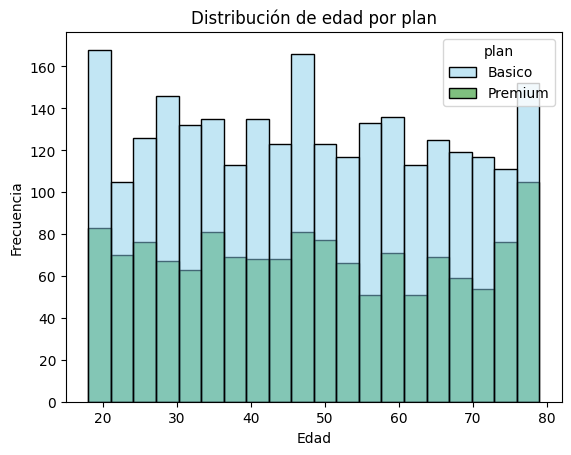

In [45]:
# Histograma para visualizar la edad (age)
import seaborn as sns

import matplotlib.pyplot as plt

sns.histplot(data=user_profile, x='age', hue='plan', bins=20, palette=['skyblue','green'])

plt.title('Distribución de edad por plan')

plt.xlabel('Edad')

plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
* La distribución de edad es relativamente simétrica.
* No se observan grandes diferencias entre usuarios de plan Básico y Premium.
* La mayoría de los usuarios se concentra entre los 30 y 65 años.

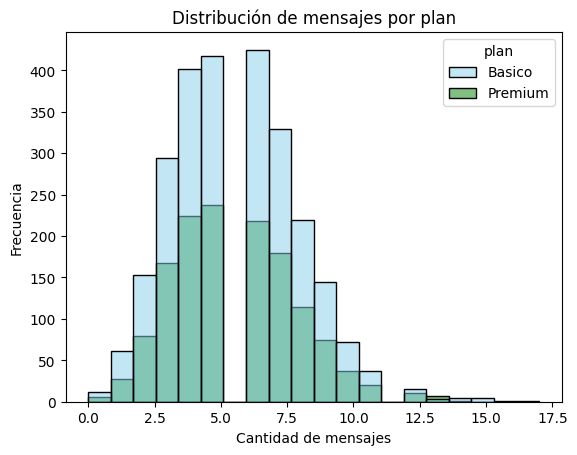

In [42]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=20, palette=['skyblue','green'])

plt.title('Distribución de mensajes por plan')

plt.xlabel('Cantidad de mensajes')

plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
* La distribución está sesgada a la derecha (muchos usuarios con pocos mensajes).
* Algunos usuarios presentan uso alto (cola larga).
* Los usuarios Premium tienden ligeramente a enviar más mensajes.

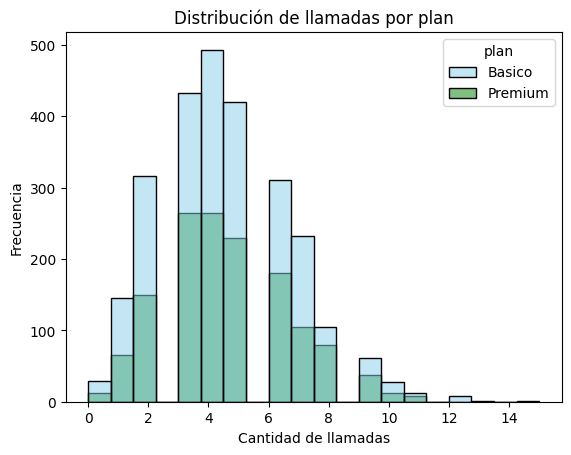

In [43]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=20, palette=['skyblue','green'])

plt.title('Distribución de llamadas por plan')

plt.xlabel('Cantidad de llamadas')

plt.ylabel('Frecuencia')

plt.show()

💡Insights: 
* La distribución está ligeramente sesgada a la derecha.
* La mayoría de los usuarios realiza entre 3 y 6 llamadas.
* No se observan diferencias significativas entre usuarios de plan Básico y Premium.
* Hay algunos valores altos que podrían considerarse posibles outliers.

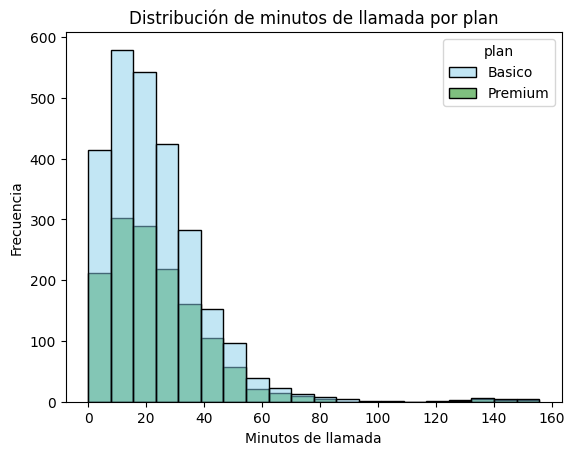

In [44]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=20, palette=['skyblue','green'])

plt.title('Distribución de minutos de llamada por plan')

plt.xlabel('Minutos de llamada')

plt.ylabel('Frecuencia')

plt.show()


💡Insights: 
* La distribución está fuertemente sesgada a la derecha.
* La mayoría de los usuarios consume pocos minutos (0–40).
* Existe una cola larga con valores altos, lo que indica usuarios con consumo intensivo.
* Los usuarios Premium muestran una ligera tendencia a acumular más minutos.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

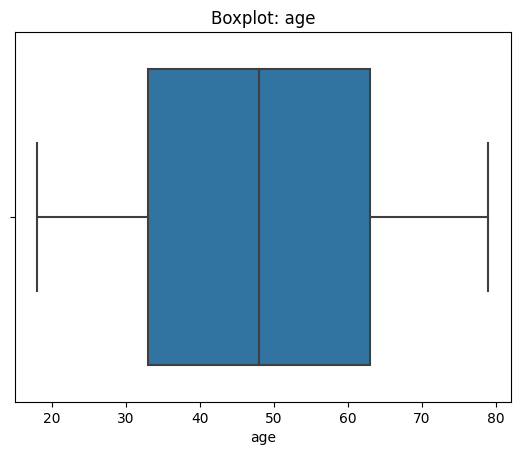

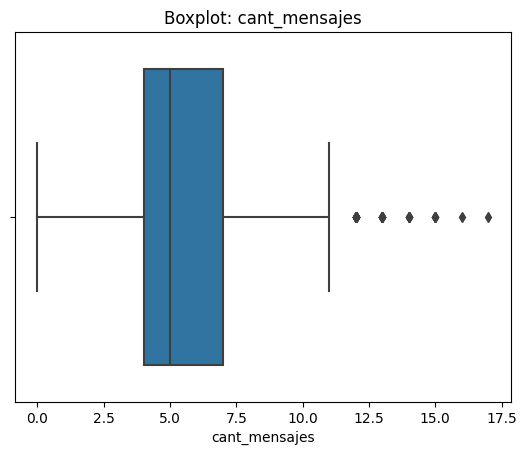

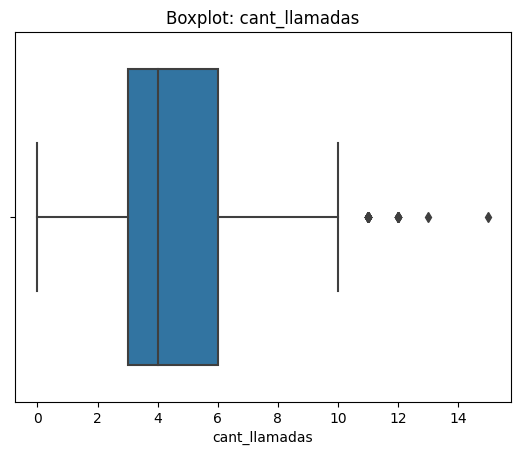

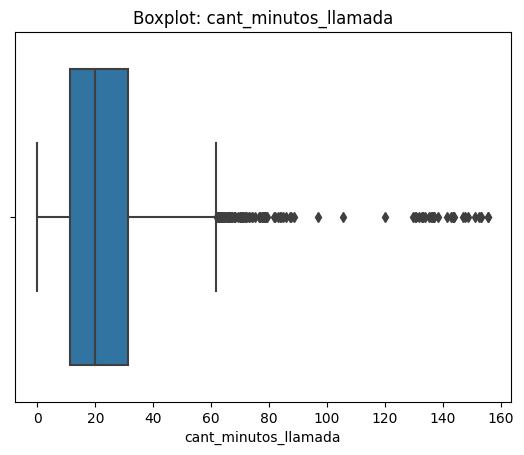

In [46]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:

    plt.figure()

    sns.boxplot(data=user_profile, x=col)

    plt.title(f'Boxplot: {col}')

    plt.show()

💡Insights: 

* Age: No presenta outliers significativos; los valores están dentro de un rango esperado (18–80 años).
* cant_mensajes: Presenta algunos valores altos (outliers) hacia la derecha, lo que indica usuarios con actividad inusualmente alta.
* cant_llamadas: Se observan algunos outliers superiores, aunque en menor cantidad que en mensajes.
* cant_minutos_llamada: Presenta varios outliers altos, evidenciando usuarios con consumo intensivo de minutos.

In [48]:
# Calcular límites con el método IQR
columnas_limites =  ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
limites = {}

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)

    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    

    limite_superior = Q3 + 1.5 * IQR

    

    limites[col] = limite_superior

    

    print(f"{col}")

    print(f"Límite superior: {limite_superior}")

    print(f"Máximo: {user_profile[col].max()}")

    print("-"*30)


cant_mensajes
Límite superior: 11.5
Máximo: 17.0
------------------------------
cant_llamadas
Límite superior: 10.5
Máximo: 15.0
------------------------------
cant_minutos_llamada
Límite superior: 61.8575
Máximo: 155.69
------------------------------


In [49]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
* cant_mensajes: Se decide mantener los outliers, ya que representan usuarios con alto uso real del servicio y no errores de captura.
* cant_llamadas: Se mantienen los outliers, pues reflejan comportamientos válidos de usuarios con mayor frecuencia de llamadas.
* cant_minutos_llamada: Se mantienen los outliers, ya que son coherentes con usuarios de alto consumo y relevantes para el análisis de uso.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [50]:
# Crear columna grupo_uso
def clasificar_uso(row):

    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:

        return 'Bajo uso'

    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:

        return 'Uso medio'

    else:

        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [51]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [52]:
# Crear columna grupo_edad
def clasificar_edad(row):

    if row['age'] < 30:

        return 'Joven'

    elif row['age'] < 60:

        return 'Adulto'

    else:

        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [53]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

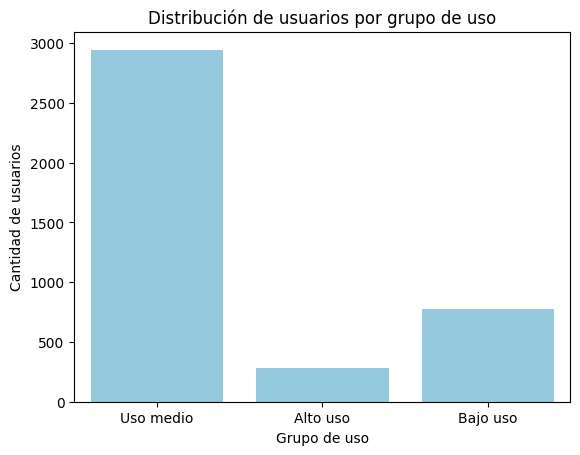

In [56]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', color='skyblue')

plt.title('Distribución de usuarios por grupo de uso')

plt.xlabel('Grupo de uso')

plt.ylabel('Cantidad de usuarios')

plt.show()

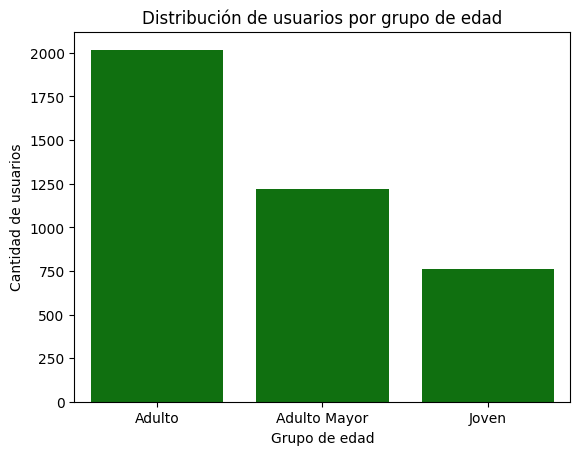

In [57]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', color='green')

plt.title('Distribución de usuarios por grupo de edad')

plt.xlabel('Grupo de edad')

plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc

Problemas detectados en los datos

* Se identificaron valores atípicos (outliers) en las variables de uso (mensajes, llamadas y minutos), especialmente en minutos de llamada.
* Estos valores representan usuarios con consumo muy alto, pero no parecen errores, sino comportamientos reales.
* No se observaron inconsistencias graves en la variable edad ni en la segmentación por plan.

 Segmentos por Edad

* La mayoría de los usuarios pertenece al grupo de Adultos (<60 años), lo que indica que este es el mercado principal.
* Los Adultos Mayores representan un segmento relevante, aunque menor.
* El grupo de Jóvenes (<30 años) es el menos representado, lo que sugiere una baja penetración en usuarios jóvenes.

 Segmentos por Nivel de Uso

* La mayoría de los usuarios se concentra en uso medio, lo que indica un consumo moderado del servicio.
* Existe un grupo más pequeño de usuarios de alto uso, que representan clientes intensivos y potencialmente más rentables.
* El grupo de bajo uso también está presente, pero en menor proporción que el uso medio.

 Esto sugiere que…

* El negocio está enfocado principalmente en usuarios adultos con consumo moderado.
* Los usuarios de alto consumo representan una oportunidad clave de monetización.
* Existe una oportunidad de crecimiento en el segmento joven, que actualmente está poco explotado.

 Recomendaciones

* Crear planes personalizados para usuarios de alto consumo, con beneficios adicionales para fidelizarlos.
* Diseñar estrategias específicas para atraer a usuarios jóvenes, como planes más accesibles o enfocados en datos/redes sociales.
* Mantener y optimizar los planes actuales para usuarios de uso medio, ya que representan la mayoría.
* Analizar más a fondo a los usuarios con alto consumo para identificar patrones y ofrecer productos premium.

En general, el análisis muestra un mercado estable con oportunidades claras de crecimiento en segmentos específicos, especialmente en usuarios jóvenes y de alto consumo.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`